In [1]:
import pandas as pd
import numpy as np

In [2]:
#load the dataset
df = pd.read_csv('Plant_Parameters.csv')

In [3]:
df.head()

,pH,Soil EC,Phosphorus,Potassium,Urea,T.S.P,M.O.P,Moisture,Temperature,Plant Type
0,6.021428,0.237700,15.987947,133.206193,45.627373,16.952809,23.362074,79.234006,52.094083,Carrots
1,6.342420,0.211844,15.305906,137.856536,59.460887,18.378723,22.143606,75.612889,51.349760,Carrots
2,6.684784,0.290343,14.778959,132.994257,53.567383,17.207365,27.448977,77.277833,61.162072,Carrots
3,6.552203,0.407055,12.328408,109.766048,41.053263,12.086209,21.630035,76.426754,72.280843,Carrots
4,6.705262,0.533824,11.215420,102.429536,37.250965,14.953550,24.008938,76.718368,58.710557,Carrots


In [4]:
#Dataset shape
df.shape

(100000, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   pH           100000 non-null  float64
 1   Soil EC      100000 non-null  float64
 2   Phosphorus   100000 non-null  float64
 3   Potassium    100000 non-null  float64
 4   Urea         100000 non-null  float64
 5   T.S.P        100000 non-null  float64
 6   M.O.P        100000 non-null  float64
 7   Moisture     100000 non-null  float64
 8   Temperature  100000 non-null  float64
 9   Plant Type   100000 non-null  object 
dtypes: float64(9), object(1)
memory usage: 7.6+ MB


In [6]:
#Check missing value
df.isnull().sum()

pH             0
Soil EC        0
Phosphorus     0
Potassium      0
Urea           0
T.S.P          0
M.O.P          0
Moisture       0
Temperature    0
Plant Type     0
dtype: int64

In [7]:
#Summary statistics
df.describe()

,pH,Soil EC,Phosphorus,Potassium,Urea,T.S.P,M.O.P,Moisture,Temperature
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,6.311596,0.710449,23.479479,146.067966,52.474345,23.246805,30.003025,68.513908,72.532048
std,0.424663,0.421481,8.756160,47.294006,20.965486,7.766893,6.580982,7.826890,8.950912
min,5.500016,0.200001,5.000354,40.001335,20.000049,10.000095,20.000120,50.004516,50.000158
25%,6.033167,0.387673,16.500213,116.637448,34.623409,17.000481,24.525720,63.015585,67.195164
50%,6.287018,0.616172,23.453419,144.624399,50.953606,22.507231,29.099600,67.986050,74.090599
75%,6.566512,0.918653,29.948292,176.011526,68.084951,28.741791,35.033828,74.286058,79.687583
max,7.499994,2.399883,39.999834,299.977196,99.997990,39.999307,49.999221,89.999598,85.998926


In [8]:
#Crop distribution
df['Plant Type'].value_counts()

Plant Type
Carrots         10000
Chili           10000
Cinnamon        10000
Corn            10000
Eggplant        10000
Rice            10000
Strawberries    10000
Sunflowers      10000
Tomato          10000
Wheat           10000
Name: count, dtype: int64

In [9]:
#Visualise features distrubtion

import matplotlib.pyplot as plt
import seaborn as sns

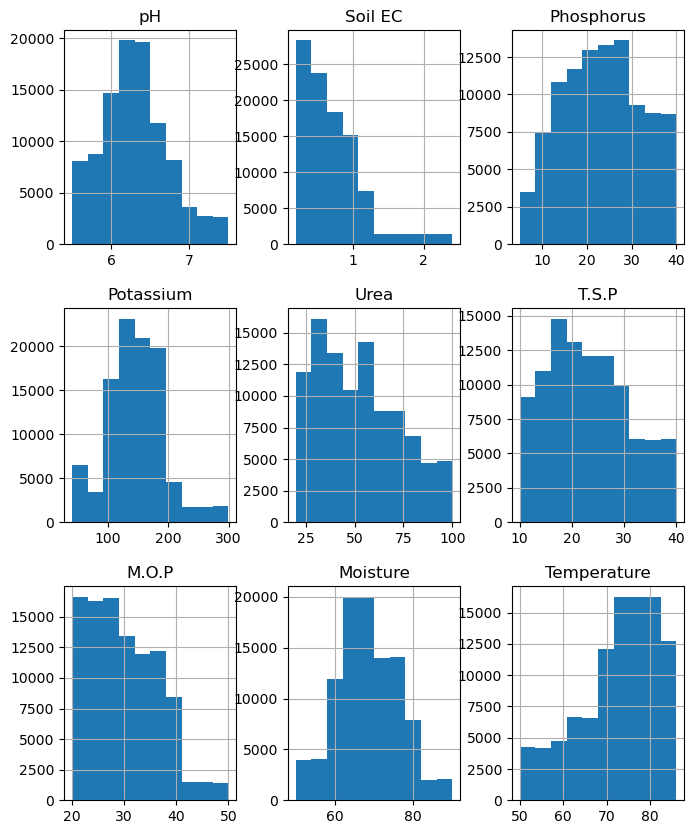

In [10]:
df.hist(figsize=(8,10))
plt.show()

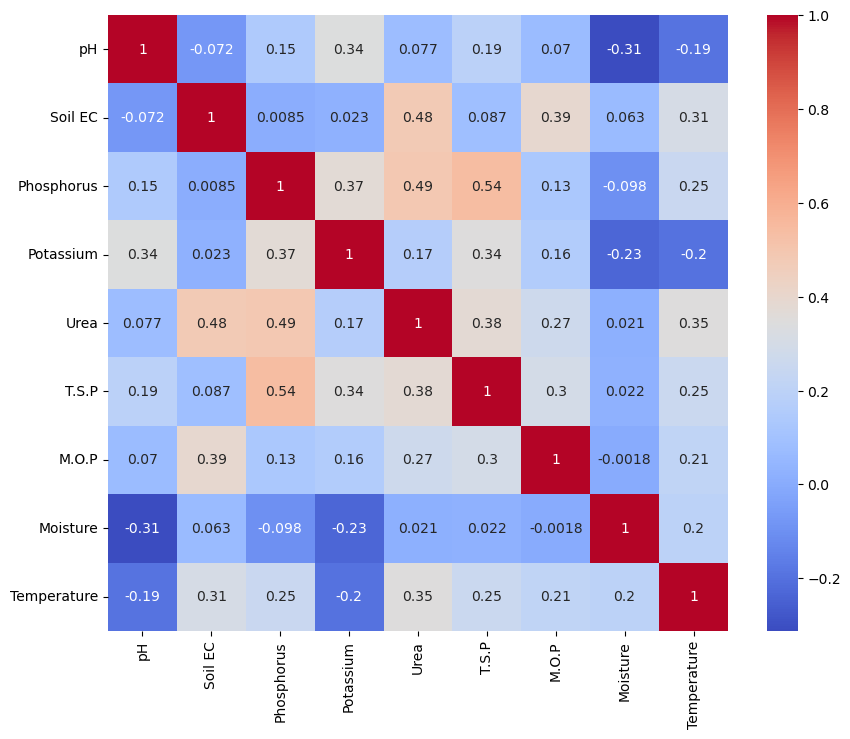

In [11]:
#correlation analysis
#selecting only the numeric columns only
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot = True, cmap ='coolwarm')
plt.show()

In [12]:
numeric_df.skew()

pH             0.410018
Soil EC        1.520764
Phosphorus     0.012161
Potassium      0.309551
Urea           0.416513
T.S.P          0.317976
M.O.P          0.516062
Moisture       0.123320
Temperature   -0.703854
dtype: float64

# The Distribution Assessment

The skewness analysis showed that most variables were approximately symmetrically distributed (skewness between -0.5 and 0.5). Soil electrical conductivity (EC) exhibited a high positive skew (1.52), indicating the presence of a small number of large values. Temperature showed moderate negative skew (-0.70). Since Random Forest is robust to skewed distributions and feature scaling was applied for SVM, no extensive transformations were required.

### 1. Random Forest Does NOT Require Feature Scaling

Random Forest is a tree-based algorithm.

Decision trees work by creating splits based on thresholds

### 2. SVM DOES Require Feature Scaling

SVM is a distance-based algorithm.

It calculates distances between data points in feature space.

Example (simplified):

𝐷
𝑖
𝑠
𝑡
𝑎
𝑛
𝑐
𝑒
=
(
𝑥
1
−
𝑥
2
)
2
+
(
𝑦
1
−
𝑦
2
)
2
Distance=
(x
1
	​

−x
2
	​

)
2
+(y
1
	​

−y
2
	​

)
2
	​


If one variable has much larger values, it dominates the distance calculation.

### Train–Test Split

Before training Random Forest and SVM, we must divide the dataset into:

Training set → used to train the model

Testing set → used to evaluate model performance

This ensures the model is evaluated on unseen data, which gives a realistic estimate of performance.



### Train–Test Split is Important

If we train and test on the same data, the model may simply memorize the dataset.

This leads to overfitting, where the model performs well on training data but poorly on new data.

The train–test split prevents this problem.

In [13]:
# Separate the features and Target
X = df.drop('Plant Type', axis=1)
y = df['Plant Type']

In [14]:
#Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [15]:
print(X_train.shape)
print(X_test.shape)

(80000, 9)
(20000, 9)


# Stratified Split
Since this is a classification problem, we want the same crop distribution in both training and testing datasets.

In [16]:
train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

[             pH   Soil EC  Phosphorus   Potassium       Urea      T.S.P  \
 25958  6.357627  0.575865   12.890218   76.899269  36.794581  18.101399   
 98509  6.525822  0.581241   18.329182  160.393040  21.294492  24.451238   
 3101   6.385429  0.412359   13.640648  132.200069  45.112509  14.518926   
 83958  6.023768  0.941992   18.840625  169.455240  69.090544  20.935191   
 61998  6.058781  0.550367   16.936933  129.888491  34.931070  19.348344   
 ...         ...       ...         ...         ...        ...        ...   
 62756  6.036956  0.503336   10.702963  110.152751  30.991802  19.557943   
 13089  6.014094  0.889067   22.170336  180.934541  80.048619  29.071507   
 1936   6.230433  0.287874   14.267806  124.786888  46.221177  15.423823   
 84092  6.761380  0.921963   15.004244  181.887799  78.686109  31.372072   
 26547  6.480998  0.680448   13.065718   43.003793  25.647786  17.188316   
 
            M.O.P   Moisture  Temperature  
 25958  36.514281  65.298315    84.543386 

### Train the Random Forest Model

The goal here is to train the model using the training dataset so it can learn the relationship between the soil/environment variables and the crop type.

In [17]:
# Import the RF Model

from sklearn.ensemble import RandomForestClassifier

# Initialize the model

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [18]:
#Train the model
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [19]:
# Now, predict the crop using the trained model
y_pred_rf = rf_model.predict(X_test)

#Check the prediction
y_pred_rf[:10]

array(['Sunflowers', 'Tomato', 'Chili', 'Corn', 'Wheat', 'Sunflowers',
       'Tomato', 'Tomato', 'Strawberries', 'Rice'], dtype=object)

In [20]:
# Save the model so that later you can load without retraining
import joblib

joblib.dump(rf_model, "random_forest_model.pkl")

#Loading it later
#rf_model = joblib.load("models/random_forest_model.pkl")

['random_forest_model.pkl']

# Model Evaluation (Random Forest)

We will evaluate using:

Accuracy

Confusion Matrix

Classification Report (Precision, Recall, F1-score)

In [21]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 0.9075


# Confusion Matrix

This shows how predictions are distributed across classes.

In [22]:
cm = confusion_matrix(y_test, y_pred_rf)
print(cm)

[[1945    0    0    0    0    0   60    0    0    0]
 [   0 1727    0    0  286    0    0    0    0    0]
 [   0    0 1977    0    0    0    0    0    0    0]
 [   0    0    0 1364    0    0    0  674    0    0]
 [   0  764    0    0 1238    0    0    0    0    0]
 [   0    0    0    0    0 2000    0    0    0    0]
 [   2    0    0    0    0    0 1983    0    0    0]
 [   0    0    0   64    0    0    0 1938    0    0]
 [   0    0    0    0    0    0    0    0 1992    0]
 [   0    0    0    0    0    0    0    0    0 1986]]


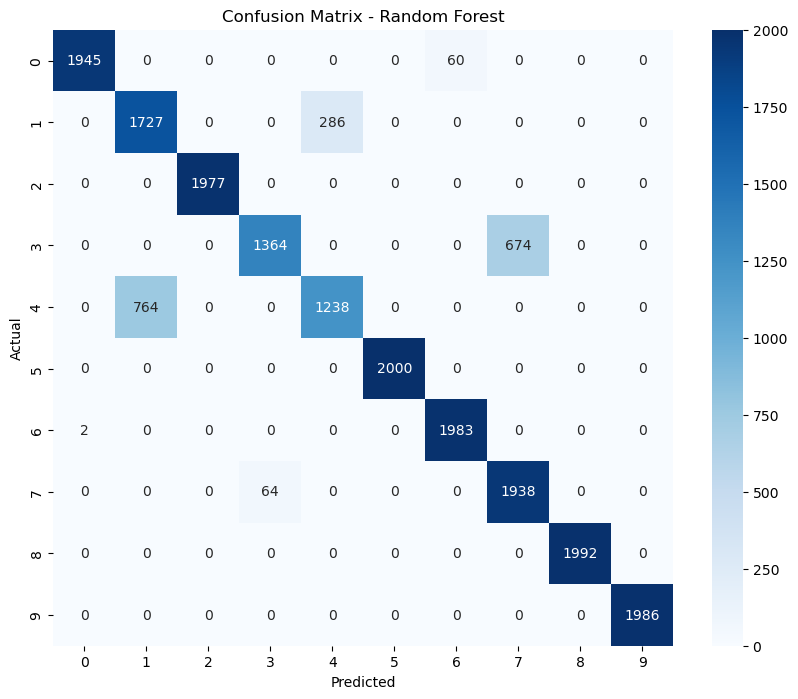

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [24]:
#Classification Report
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

     Carrots       1.00      0.97      0.98      2005
       Chili       0.69      0.86      0.77      2013
    Cinnamon       1.00      1.00      1.00      1977
        Corn       0.96      0.67      0.79      2038
    Eggplant       0.81      0.62      0.70      2002
        Rice       1.00      1.00      1.00      2000
Strawberries       0.97      1.00      0.98      1985
  Sunflowers       0.74      0.97      0.84      2002
      Tomato       1.00      1.00      1.00      1992
       Wheat       1.00      1.00      1.00      1986

    accuracy                           0.91     20000
   macro avg       0.92      0.91      0.91     20000
weighted avg       0.92      0.91      0.91     20000



# Feature Importance (Very Important Insight)

Random Forest can tell you which variables are most important.

In [25]:
import pandas as pd

feature_importances = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(feature_importances)

Moisture       0.215405
Soil EC        0.208211
Potassium      0.113657
pH             0.106306
Urea           0.097985
Temperature    0.089127
Phosphorus     0.081360
T.S.P          0.063038
M.O.P          0.024910
dtype: float64


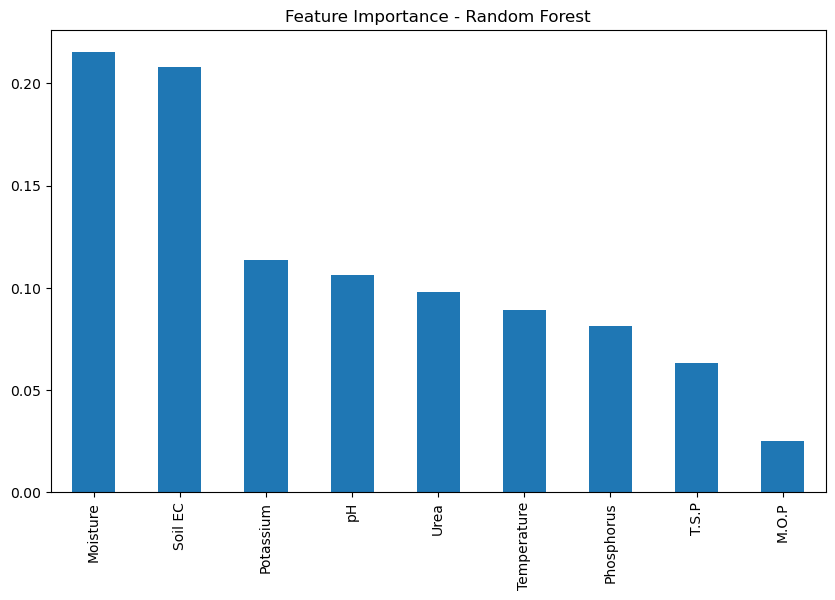

In [26]:
#Plotting the features

feature_importances.plot(kind='bar', figsize=(10,6))
plt.title("Feature Importance - Random Forest")
plt.show()

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)

In [28]:
#import the SVM model
from sklearn.svm import SVC

#Initialize the model
svm_model = SVC(
    kernel='rbf',   # best default choice
    C=1.0,
    gamma='scale'
)

| Parameter      | Meaning                               |
| -------------- | ------------------------------------- |
| `kernel='rbf'` | handles nonlinear relationships       |
| `C`            | controls model flexibility            |
| `gamma`        | controls influence of each data point |


In [29]:
# train the model

svm_model.fit(X_train_scaled, y_train)

#Make Prediction
y_pred_svm = svm_model.predict(X_test_scaled)

#Save the model
joblib.dump(svm_model, "svm_model.pkl")

['svm_model.pkl']

In [30]:
#Modela evaluation
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print("SVM Accuracy:", accuracy_svm)

SVM Accuracy: 0.8986


<Axes: >

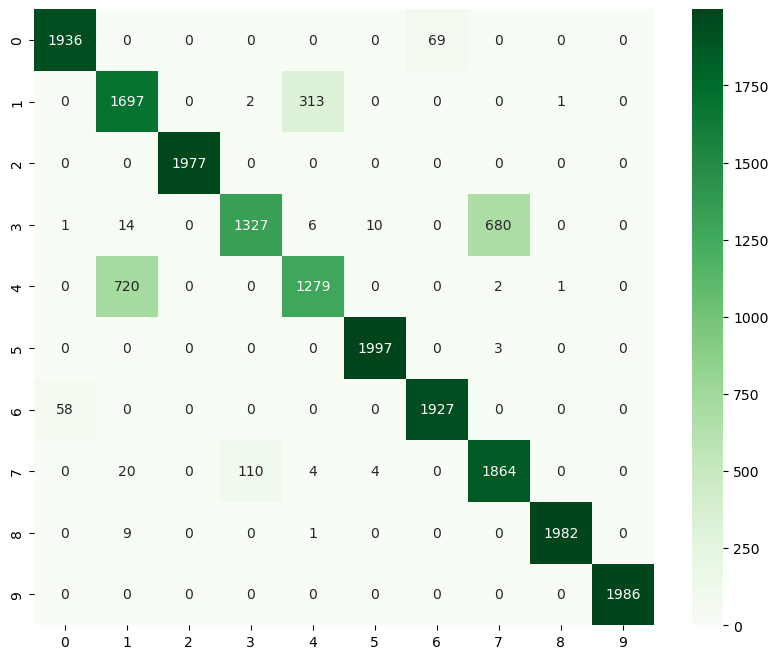

In [39]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens')

# Model Tuning to increase the model performance

In [34]:
# Create sample data
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

#rf_grid.fit(X_train, y_train)

In [35]:
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [36]:
#Initialize the grid
rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=rf_params,
    cv=3,
    n_jobs=-1,
    verbose=2
)

In [38]:
rf_grid.fit(X_train, y_train)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [39]:
rf_grid.best_params_
rf_grid.best_score_

np.float64(0.912612523566736)

In [40]:
y_pred_rf_tuned = rf_grid.best_estimator_.predict(X_test)

#from sklearn.metrics import accuracy_score

accuracy_rf_tuned = accuracy_score(y_test, y_pred_rf_tuned)

print("Tuned RF Test Accuracy:", accuracy_rf_tuned)

Tuned RF Test Accuracy: 0.91225


# Building Model pipeline for posibel deployment

In [41]:
# RF pipeline

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ('model', RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

In [42]:
# Training the pipeline
rf_pipeline.fit(X_train, y_train)

,steps,"[('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'


In [44]:
# Test the pipeline
y_pred_pipeline = rf_pipeline.predict(X_test)

In [46]:
# Evaluate the pipeline
from sklearn.metrics import accuracy_score

accuracy_pipeline = accuracy_score(y_test, y_pred_pipeline)
print("Pipeline Accuracy:", accuracy_pipeline)

Pipeline Accuracy: 0.9075


In [47]:
# Save the final pipeline
import joblib

joblib.dump(rf_pipeline, "final_rf_pipeline.pkl")

['final_rf_pipeline.pkl']

In [58]:
# Load the pipeline
rf_pipeline = joblib.load("final_rf_pipeline.pkl")

pd.Series(rf_pipeline.predict(X_test)).value_counts()

Sunflowers      2612
Chili           2491
Strawberries    2043
Rice            2000
Tomato          1992
Wheat           1986
Cinnamon        1977
Carrots         1947
Eggplant        1524
Corn            1428
Name: count, dtype: int64

In [52]:
# Testing new data
import pandas as pd

new_data = pd.DataFrame([{
    'pH': 6.5,
    'Soil EC': 1.2,
    'Phosphorus': 40,
    'Potassium': 50,
    'Urea': 30,
    'T.S.P': 20,
    'M.O.P': 25,
    'Moisture': 60,
    'Temperature': 28
}])

prediction = rf_pipeline.predict(new_data)

print("Predicted Crop:", prediction[0])

Predicted Crop: Cinnamon


In [59]:
ph = st.number_input("Soil pH", 0.0, 14.0, 6.5)
soil_ec = st.number_input("Soil EC", 0.0, 10.0, 1.0)
phosphorus = st.number_input("Phosphorus", 0, 100, 40)
potassium = st.number_input("Potassium", 0, 100, 50)
urea = st.number_input("Urea", 0, 100, 30)
tsp = st.number_input("T.S.P", 0, 100, 20)
mop = st.number_input("M.O.P", 0, 100, 25)
moisture = st.number_input("Moisture", 0, 100, 60)
temperature = st.number_input("Temperature", 0.0, 50.0, 25.0)

NameError: name 'st' is not defined

# Build simpler Streamline app to test the model

In [60]:
import streamlit as st
import pandas as pd
import joblib

# Load model
model = joblib.load("final_rf_pipeline.pkl")

st.title("Crop Prediction App")

st.write("Enter soil and environmental conditions:")

# Inputs
ph = st.number_input("Soil pH", 0.0, 14.0, 6.5)
soil_ec = st.number_input("Soil EC", 0.0, 10.0, 1.0)
phosphorus = st.number_input("Phosphorus", 0, 100, 40)
potassium = st.number_input("Potassium", 0, 100, 50)
urea = st.number_input("Urea", 0, 100, 30)
tsp = st.number_input("T.S.P", 0, 100, 20)
mop = st.number_input("M.O.P", 0, 100, 25)
moisture = st.number_input("Moisture", 0, 100, 60)
temperature = st.number_input("Temperature (°C)", 0.0, 50.0, 25.0)

# Predict
if st.button("Predict Crop"):
    input_data = pd.DataFrame([{
        'pH': ph,
        'Soil EC': soil_ec,
        'Phosphorus': phosphorus,
        'Potassium': potassium,
        'Urea': urea,
        'T.S.P': tsp,
        'M.O.P': mop,
        'Moisture': moisture,
        'Temperature': temperature
    }])

st.write("Input data:

2026-03-22 07:30:19.207 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-22 07:30:19.463 
  command:

    streamlit run C:\Users\HP\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-03-22 07:30:19.465 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-22 07:30:19.466 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-22 07:30:19.468 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-22 07:30:19.469 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-22 07:30:19.470 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-22 07:30:19.471 Thread 'MainThread': missi